# 多模态模型调试指南

本笔记本展示如何:
1. 加载和使用 TorchVision 中的 ViT 模型
2. 安装 CLIP 和 BLIP
3. 进行推理和调试
4. 部署优化建议

## 1. ViT (TorchVision) - 立即可用

In [2]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# 检查 GPU 可用性
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'使用设备: {device}')
print(f'PyTorch 版本: {torch.__version__}')

使用设备: cpu
PyTorch 版本: 2.7.0


In [3]:
# 列出所有 ViT 模型
vit_models = [
    'vit_b_16',  # Base, patch=16
    'vit_b_32',  # Base, patch=32
    'vit_l_16',  # Large, patch=16
    'vit_l_32',  # Large, patch=32
    'vit_h_14',  # Huge, patch=14
]

print('可用的 ViT 模型:')
for m in vit_models:
    print(f'  - {m}')

可用的 ViT 模型:
  - vit_b_16
  - vit_b_32
  - vit_l_16
  - vit_l_32
  - vit_h_14


In [4]:
# 加载 ViT 模型 (第一次会下载预训练权重)
print('加载 vit_b_16...')
model = models.vit_b_16(pretrained=True, progress=True)
model = model.to(device)
model.eval()

print(f'✅ 模型加载完成')
print(f'总参数: {sum(p.numel() for p in model.parameters()):,}')

加载 vit_b_16...


/Users/zhuji_m4pro/code/LLM_from_scrach/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/zhuji_m4pro/code/LLM_from_scrach/.conda/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /Users/zhuji_m4pro/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [03:30<00:00, 1.64MB/s] 


✅ 模型加载完成
总参数: 86,567,656


图像大小: (1200, 1602)


/Users/zhuji_m4pro/code/LLM_from_scrach/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhuji_m4pro/code/LLM_from_scrach/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhuji_m4pro/code/LLM_from_scrach/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/zhuji_m4pro/code/LLM_from_scrach/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


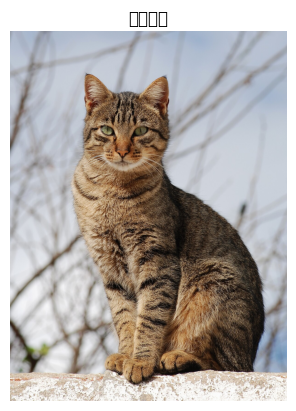

In [7]:
# 定义图像预处理
def get_transforms():
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

transform = get_transforms()

# 从 URL 加载示例图像
img_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4d/Cat_November_2010-1a.jpg/1200px-Cat_November_2010-1a.jpg"
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; ARM Mac OS X)'}
response = requests.get(img_url, headers=headers)
img = Image.open(BytesIO(response.content)).convert('RGB')

print(f'图像大小: {img.size}')
plt.imshow(img)
plt.axis('off')
plt.title('输入图像')
plt.show()

In [17]:
# 推理
img_tensor = transform(img).unsqueeze(0).to(device)

print(f'输入张量形状: {img_tensor.shape}')
print(f'输入范围: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]')

with torch.no_grad():
    output = model(img_tensor)

print(f'输出形状: {output.shape}')
print(f'输出范围: [{output.min():.3f}, {output.max():.3f}]')

输入张量形状: torch.Size([1, 3, 224, 224])
输入范围: [-2.015, 2.518]
输出形状: torch.Size([1, 1000])
输出范围: [-0.909, 8.196]


In [13]:
import json

import torchvision 
weights = torchvision.models.ResNet50_Weights.DEFAULT
labels = weights.meta["categories"]
labels[282]

'tiger cat'

In [9]:
# 获取 Top-5 预测
probabilities = torch.nn.functional.softmax(output, dim=1)
top5_prob, top5_idx = torch.topk(probabilities, 5, dim=1)

print('Top-5 预测:')
for prob, idx in zip(top5_prob[0], top5_idx[0]):
    print(f'  类别 {idx.item()}: {prob.item():.4f}')

Top-5 预测:
  类别 282: 0.4544
  类别 285: 0.2656
  类别 281: 0.1538
  类别 287: 0.0031
  类别 292: 0.0005


## 2. CLIP 安装与使用

In [ ]:
# 方式 1: OpenAI CLIP
# !pip install git+https://github.com/openai/CLIP.git

# 方式 2: Open CLIP (推荐,更轻量)
# !pip install open-clip-torch

print('CLIP 安装命令已列出')
print('安装后可以使用:')
print('  import clip')
print('  model, preprocess = clip.load("ViT-B/32", device=device)')

## 3. BLIP 安装与使用

In [ ]:
# BLIP 安装
# !pip install salesforce-lavis

print('BLIP 安装命令:')
print('  pip install salesforce-lavis')
print('')
print('BLIP 使用示例:')
print('''
from lavis.models import load_model_and_preprocess

model, vis_processors, txt_processors = load_model_and_preprocess(
    name="blip_caption",
    model_type="base_coco",
    is_eval=True,
    device=device
)
''')

## 4. 性能优化与部署

In [ ]:
# 方式 1: 模型量化
import copy

quantized_model = copy.deepcopy(model)
quantized_model = torch.quantization.quantize_dynamic(
    quantized_model,
    {torch.nn.Linear},
    dtype=torch.qint8
)

# 比较大小
import os
torch.save(model.state_dict(), '/tmp/model.pth')
torch.save(quantized_model.state_dict(), '/tmp/model_quantized.pth')

original_size = os.path.getsize('/tmp/model.pth') / 1024 / 1024
quantized_size = os.path.getsize('/tmp/model_quantized.pth') / 1024 / 1024

print(f'原始模型: {original_size:.1f} MB')
print(f'量化模型: {quantized_size:.1f} MB')
print(f'压缩率: {100 * (1 - quantized_size / original_size):.1f}%')

In [ ]:
# 方式 2: ONNX 导出 (跨平台)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    '/tmp/vit_b_16.onnx',
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch_size'}},
    verbose=False
)

print('✅ ONNX 模型已导出到 /tmp/vit_b_16.onnx')

## 5. 批量推理优化

In [ ]:
import time

# 准备一批图像
batch_size = 8
batch_images = torch.randn(batch_size, 3, 224, 224).to(device)

# 基准测试
n_iterations = 10

# 预热
with torch.no_grad():
    _ = model(batch_images)

# 计时
start = time.time()
with torch.no_grad():
    for _ in range(n_iterations):
        output = model(batch_images)
end = time.time()

avg_time = (end - start) / n_iterations / batch_size * 1000
throughput = batch_size * n_iterations / (end - start)

print(f'批大小: {batch_size}')
print(f'单张图像平均延迟: {avg_time:.1f} ms')
print(f'吞吐量: {throughput:.1f} img/s')

## 总结

In [ ]:
summary = """
多模态模型选择指南:

【ViT - TorchVision (已安装)】
  用途: 图像分类
  优点: 立即可用，高精度，支持多种大小
  缺点: 速度较慢

【CLIP - 需安装】
  用途: 文本-图像匹配，零样本分类
  优点: 开放性强，支持自定义类别
  缺点: 输出两个模型

【BLIP - 需安装】
  用途: 图像标注，VQA，图文检索
  优点: 端到端的多模态理解
  缺点: 模型较大

【部署建议】
  1. 使用 torch.quantization 减少模型大小
  2. 导出为 ONNX 以支持跨平台部署
  3. 批量推理提高吞吐量
  4. 考虑使用 TorchServe 或 FastAPI 部署
"""

print(summary)